# 01 - Exploración del Dataset PBDB

Exploración inicial del dataset de megadepredadores vertebrados
extraído de la Paleobiology Database (PBDB) API v1.2.

**Objetivo:** Entender la estructura del dataset, identificar 
problemas de calidad y definir el plan de limpieza.

**Fuente:** `data/raw/pbdb_raw.csv` - generado por `src/collectors/pbdb.py`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Estilo general
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/raw/pbdb_raw.csv')
print(f'Dataset: {df.shape[0]:,} géneros - {df.shape[1]} columnas')
df.head()

Dataset: 3,859 géneros - 7 columnas


,Nombre,Grupo,Clase,Primera_aparicion,Ultima_aparicion,Dieta,Entorno
0,Saltopus,Dinosauria,Saurischia,237.0,205.7,carnivore,terrestrial
1,Anteavis,Dinosauria,Reptilia,237.0,227.3,carnivore,terrestrial
2,Avalonia,Dinosauria,Reptilia,205.7,201.4,carnivore,terrestrial
3,Ovoraptor,Dinosauria,Reptilia,83.6,72.2,carnivore,terrestrial
4,Halticosaurus,Dinosauria,Reptilia,237.0,201.4,carnivore,terrestrial


## 1. Vista general

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3859 entries, 0 to 3858
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nombre             3859 non-null   object 
 1   Grupo              3859 non-null   object 
 2   Clase              3859 non-null   object 
 3   Primera_aparicion  3859 non-null   float64
 4   Ultima_aparicion   3859 non-null   float64
 5   Dieta              3859 non-null   object 
 6   Entorno            2626 non-null   object 
dtypes: float64(2), object(5)
memory usage: 211.2+ KB


## 2. Distribuicion por Grupos Taxonómicos

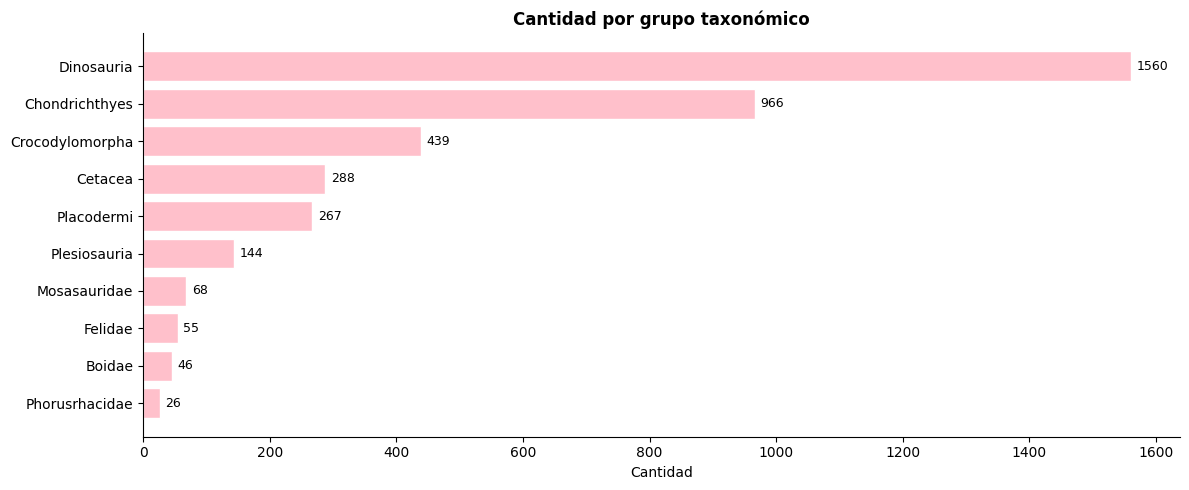

Grupo
Dinosauria         1560
Chondrichthyes      966
Crocodylomorpha     439
Cetacea             288
Placodermi          267
Plesiosauria        144
Mosasauridae         68
Felidae              55
Boidae               46
Phorusrhacidae       26
Name: count, dtype: int64


In [6]:
conteo = df['Grupo'].value_counts()

fig, ax = plt.subplots()
bars = ax.barh(conteo.index, conteo.values, color='pink', edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Cantidad')
ax.set_title('Cantidad por grupo taxonómico', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(conteo)

In [20]:
df['Clase'].value_counts()

Clase
Reptilia          1269
Aves              1013
Chondrichthyes     966
Mammalia           343
Placodermi         267
Saurischia           1
Name: count, dtype: int64

## 3. Rango temporal de los registros

Cada grupo tiene una `Primera_aparicion` y una `Ultima_aparicion` en millones de años. Calculamos la duracion de existencia de cada grupo.

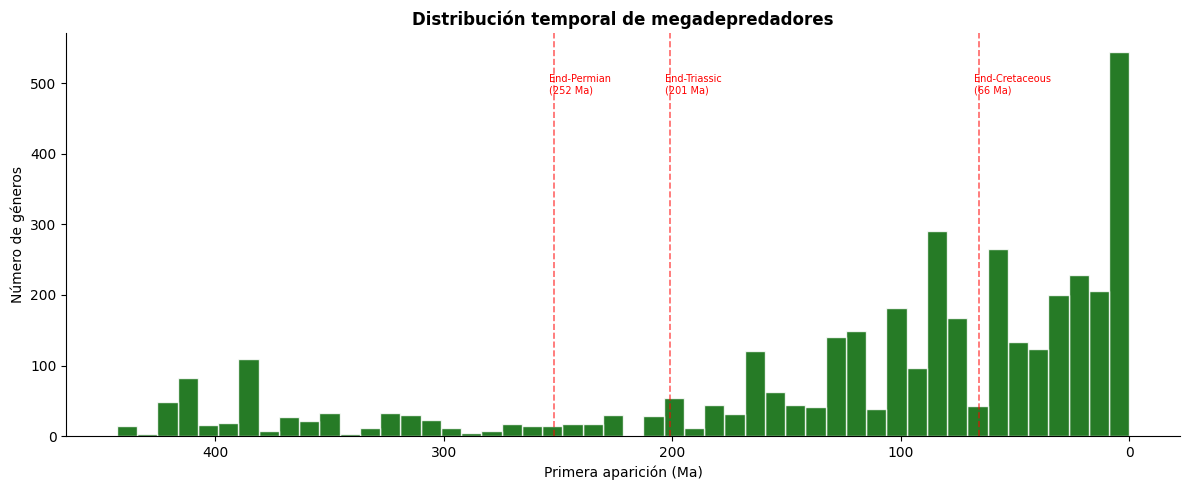

In [ ]:
df['Duracion_Ma'] = df['Primera_aparicion'] - df['Ultima_aparicion']

fig, ax = plt.subplots()
ax.hist(df['Primera_aparicion'], bins=50, color='darkgreen', edgecolor='white', alpha=0.85)
ax.set_xlabel('Primera aparición (Ma)')
ax.set_ylabel('Número de géneros')
ax.set_title('Distribución temporal de megadepredadores', fontweight='bold')
ax.invert_xaxis()

# Líneas de extinciones masivas
extinciones = {
    'End-Cretaceous\n(66 Ma)': 66,
    'End-Triassic\n(201 Ma)': 201,
    'End-Permian\n(252 Ma)': 252,
}
for nombre, ma in extinciones.items():
    ax.axvline(ma, color='red', linestyle='--', alpha=0.6, linewidth=1.2)
    ax.text(ma + 2, ax.get_ylim()[1] * 0.85, nombre, fontsize=7, color='red')

plt.tight_layout()
plt.show()

## 4. Top 15 - Grupos con Mayor Duración de Dominancia

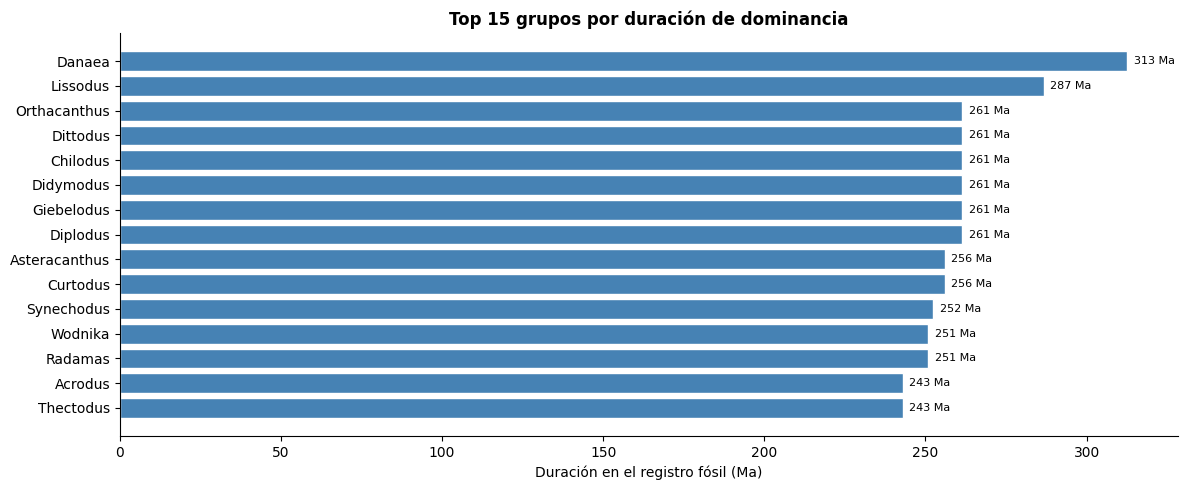

In [11]:
top15 = df.nlargest(15, 'Duracion_Ma')[['Nombre', 'Grupo', 'Clase', 'Duracion_Ma']]

colores = {
    'Chondrichthyes': 'steelblue',
    'Reptilia': 'olivedrab',
    'Mammalia': 'darkorange',
    'Placodermi': 'slategray',
    'Aves': 'mediumpurple'
}

fig, ax = plt.subplots()
for i, (_, row) in enumerate(top15.iterrows()):
    color = colores.get(row['Clase'], 'gray')
    bar = ax.barh(row['Nombre'], row['Duracion_Ma'], color=color, edgecolor='white')
    ax.text(row['Duracion_Ma'] + 2, i, f"{row['Duracion_Ma']:.0f} Ma", va='center', fontsize=8)

ax.set_xlabel('Duración en el registro fósil (Ma)')
ax.set_title('Top 15 grupos por duración de dominancia', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Problemas de Calidad Encontrados

Se identificaron problemas que deben resolverse antes del procesamiento.

In [16]:
# Duplicados
duplicados = df[df.duplicated(subset='Nombre', keep=False)].sort_values('Nombre')
print(f'Duplicados: {df.duplicated(subset="Nombre").sum()} géneros repetidos')
print(duplicados[['Nombre', 'Grupo', 'Clase']].head(10).to_string(index=False))

Duplicados: 39 géneros repetidos
        Nombre          Grupo          Clase
 Andalgalornis Phorusrhacidae           Aves
 Andalgalornis     Dinosauria           Aves
  Andrewsornis Phorusrhacidae           Aves
  Andrewsornis     Dinosauria           Aves
  Archaeolamna Chondrichthyes Chondrichthyes
  Archaeolamna Chondrichthyes Chondrichthyes
Brachyrhizodus Chondrichthyes Chondrichthyes
Brachyrhizodus Chondrichthyes Chondrichthyes
      Chimaera Chondrichthyes Chondrichthyes
      Chimaera     Dinosauria       Reptilia


In [19]:
# Nulos en Entorno
print('\nNulos por columna:')
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(1)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje': pct})
print(resumen[resumen['Nulos'] > 0])


Nulos por columna:
         Nulos  Porcentaje
Entorno   1233        32.0


## 6. Conclusiones y Próximos Pasos

**Lo que encontramos:**
- 3,859 géneros cubriendo 540 millones de años de historia
- 10 grupos taxonómicos representados
- Chondrichthyes domina en cantidad, enorme diversidad de tiburones a través del tiempo
- Clasificación de `Clase` correcta en todos los grupos

**Problemas pendientes para** `src/processors/cleaner.py`:
1. 39 duplicados por nombre de género
2. 1,233 nulos en columna `Entorno` - imputables desde `Clase`

**Siguiente fase:** `src/processors/cleaner.py`  limpieza y normalización del dataset.